<a href="https://colab.research.google.com/github/AshishPal20/Machine-Learning-/blob/main/function_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats  # use to plot QQ plot

import sklearn

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv("/content/Titanic-Dataset.csv", usecols=["Age", "Fare", "Survived"])

In [ ]:
df["Age"].fillna(df["Age"].mean(), inplace=True)

/tmp/ipykernel_9850/1809399462.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

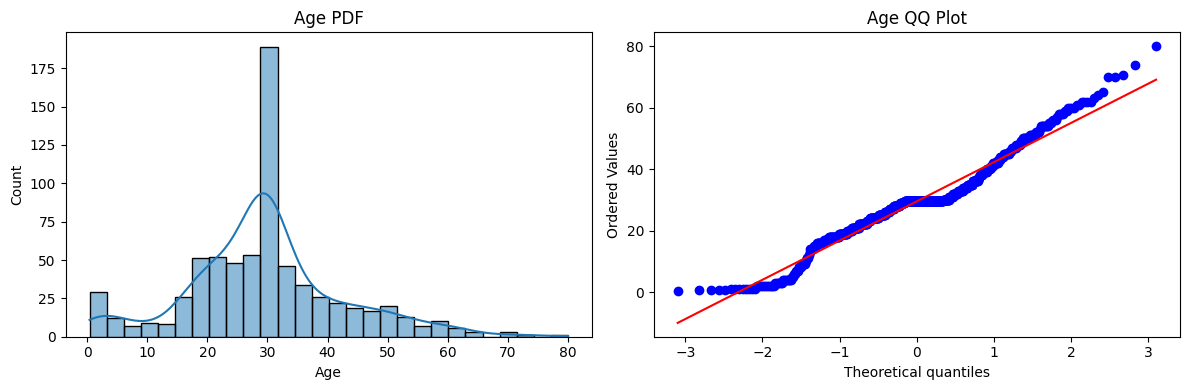

In [ ]:
plt.figure(figsize=(12, 4))

# PDF / distribution plot
plt.subplot(1, 2, 1)
sns.histplot(X_train["Age"], kde=True)
plt.title("Age PDF")


# QQ plot
plt.subplot(1, 2, 2)
stats.probplot(X_train["Age"].dropna(), dist="norm", plot=plt)
plt.title("Age QQ Plot")

plt.tight_layout()
plt.show()

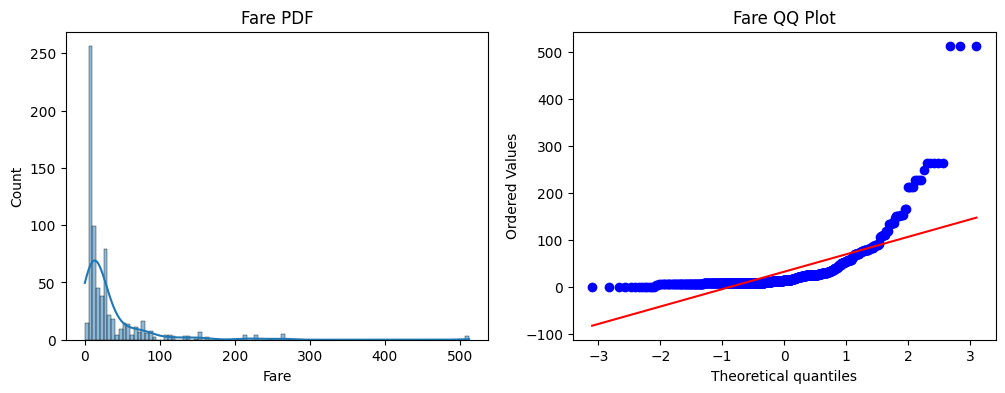

In [ ]:
plt.figure(figsize=(12, 4))

# PDF for Fare
plt.subplot(1, 2, 1)
sns.histplot(X_train["Fare"], kde=True)
plt.title("Fare PDF")

# QQ plot for Fare
plt.subplot(1, 2, 2)
stats.probplot(X_train["Fare"].dropna(), dist="norm", plot=plt)
plt.title("Fare QQ Plot")

plt.show()

In [ ]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

clf2 = DecisionTreeClassifier()
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

print("Accuracy LR:", accuracy_score(y_test, y_pred))
print("Accuracy DT:", accuracy_score(y_test, y_pred2))

Accuracy LR: 0.6480446927374302
Accuracy DT: 0.6759776536312849


In [ ]:
trf = FunctionTransformer(func = np.log1p)

In [ ]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [ ]:
clf = LogisticRegression()
clf.fit(X_train_transformed, y_train)

clf2 = DecisionTreeClassifier()
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

print("Accuracy LR:", accuracy_score(y_test, y_pred))
print("Accuracy DT:", accuracy_score(y_test, y_pred2))

Accuracy LR: 0.6815642458100558
Accuracy DT: 0.6703910614525139


In [ ]:
#  Cross validation to see that accuracy we got is correct or not
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
scores = cross_val_score(clf, X_transformed, y, cv=10)

clf2 = DecisionTreeClassifier()
scores2 = cross_val_score(clf2, X_transformed, y, cv=10)

print("Accuracy LR:", scores.mean())
print("Accuracy DT:", scores2.mean())

Accuracy LR: 0.678027465667915
Accuracy DT: 0.6610986267166044


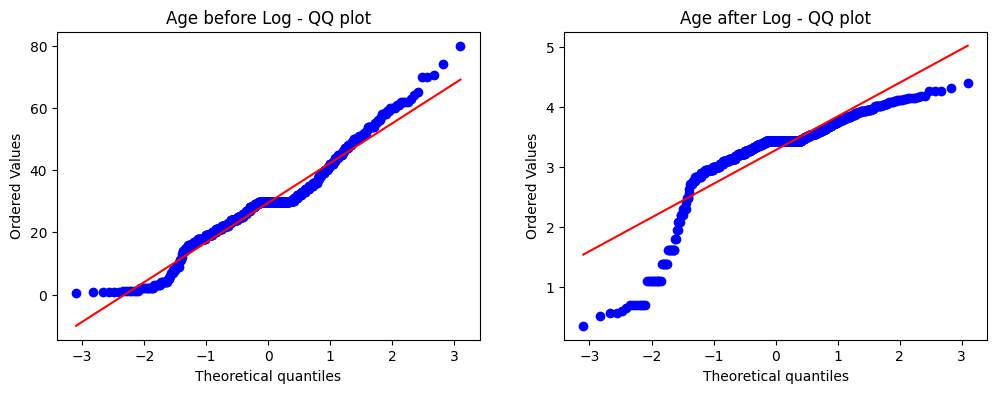

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
stats.probplot(X_train["Age"], dist = "norm", plot = plt)
plt.title("Age before Log - QQ plot")

plt.subplot(1,2,2)
stats.probplot(X_train_transformed["Age"], dist = "norm", plot = plt)
plt.title("Age after Log - QQ plot")

plt.show()

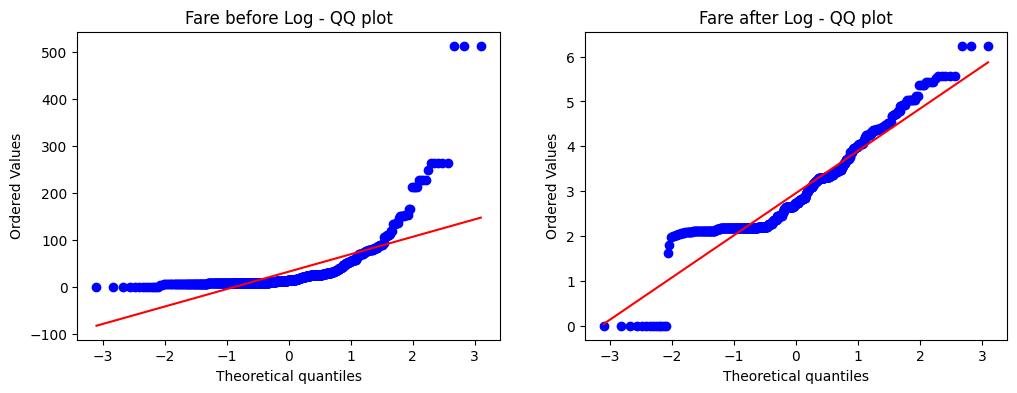

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
stats.probplot(X_train["Fare"], dist = "norm", plot = plt)
plt.title("Fare before Log - QQ plot")

plt.subplot(1,2,2)
stats.probplot(X_train_transformed["Fare"], dist = "norm", plot = plt)
plt.title("Fare after Log - QQ plot")

plt.show()

In [ ]:
def apply_transform(transform):
  X = df.iloc[:, 1:3]
  y = df.iloc[:, 0]

  trf =  ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])], remainder="passthrough")
  X_transformed = trf.fit_transform(X)
  clf = LogisticRegression()
  scores = cross_val_score(clf, X_transformed, y, cv=10)
  print("Accuracy LR:", scores.mean())

  plt.figure(figsize=(12, 4))

  plt.subplot(1,2,1)
  stats.probplot(X["Fare"], dist = "norm", plot = plt)
  plt.title("Fare before Transform")

  plt.subplot(1,2,2)
  stats.probplot(X_transformed[:,0], dist = "norm", plot = plt)
  plt.title("Fare after Transform")

  plt.show()

Accuracy LR: 0.6589013732833957


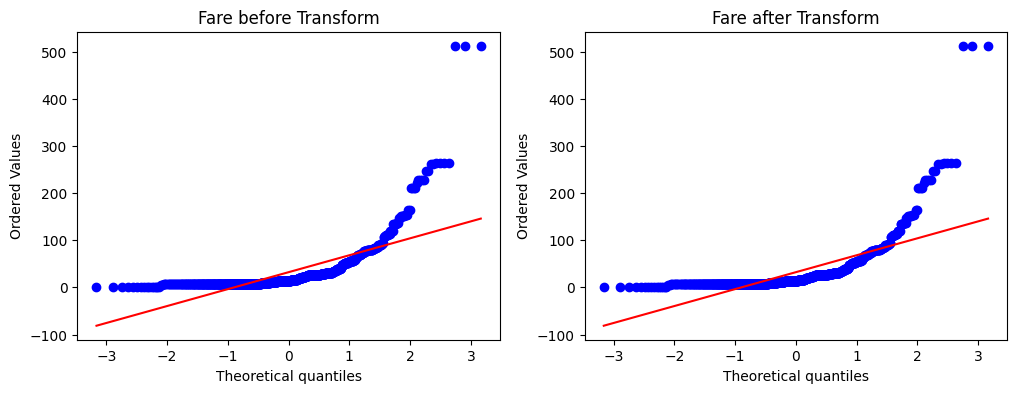

In [ ]:
apply_transform(lambda x: x)

Accuracy LR: 0.61729088639201


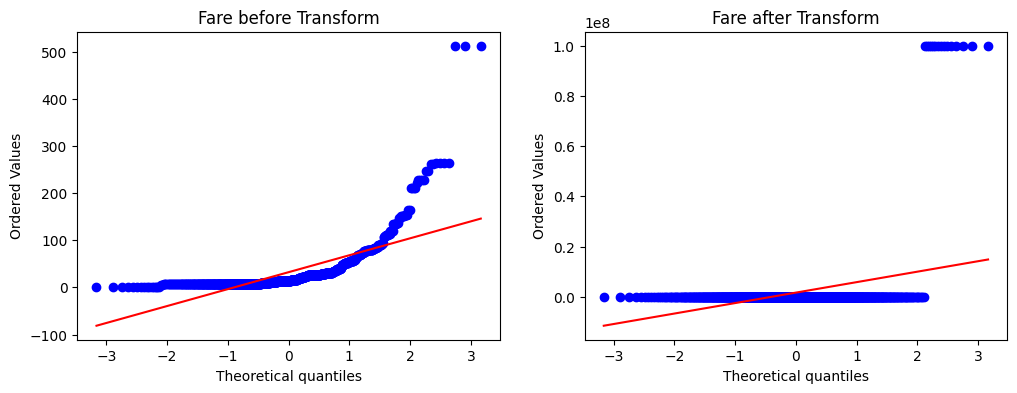

In [ ]:
apply_transform(lambda x: 1/(x+0.00000001))